# STREME / TOMTOM / FIMO pipeline

This notebook configures, runs and summarizes the motif pipeline. The reusable
implementation is in `streme_pipeline.py`; the same code is used by the Slurm
array jobs.


## Setup


In [34]:
from pathlib import Path
import pandas as pd

from streme_pipeline import (
    PipelineConfig,
    PipelineParameters,
    STAGES,
    build_status,
    combine_result_tables,
    discover_fastas,
    export_fimo_for_binding_bench,
    run_all_stages,
    run_pipeline_for_fasta,
    save_analysis_tables,
    save_summaries,
)


In [35]:
config = PipelineConfig.default(
    project=Path("/s/project/ml4rg_students/2026/project15")
)
config.validate()

fastas = discover_fastas(config.fasta_dir)
parameters = PipelineParameters(
    streme_time=1800,
    minw=6,
    maxw=20,
    nmotifs=10,
    fimo_thresh="1e-4",
    fimo_max_stored_scores=100_000,
    fimo_skip_matched_sequence=False,
)

print(f"Found {len(fastas)} FASTA files")
print("FASTA directory:", config.fasta_dir)
print("Result directory:", config.result_dir)
print("JASPAR database:", config.jaspar_fungi)


Found 1402 FASTA files
FASTA directory: /s/project/ml4rg_students/2026/project15/working/sequence_datasets_fastas
Result directory: /s/project/ml4rg_students/2026/project15/working/streme_results
JASPAR database: /s/project/ml4rg_students/2026/project15/working/jaspar/JASPAR2026_CORE_fungi_non-redundant_pfms_meme.txt


The pipeline writes a `.pipeline_done.json` next to each successful
result. New results are only reused when their command and input signatures
match. Existing results from the old notebook have no manifest and are accepted
as a legacy cache by default.


## Status


In [5]:
!squeue -j 19487321

slurm_load_jobs error: Invalid job id specified


In [6]:
!sacct -X -j 19488093,19489703 --format=JobID,JobName,State,ExitCode,Elapsed,MaxRSS

JobID           JobName      State ExitCode    Elapsed     MaxRSS 
------------ ---------- ---------- -------- ---------- ---------- 
19488093     streme-n1+  COMPLETED      0:0   03:27:30            
19489703     streme-n1+  COMPLETED      0:0   04:29:47            


## Test one FASTA


In [37]:
prediction_path = export_fimo_for_binding_bench(
    config,
    test_fasta,
    result_key="fimo_streme_tsv",
)

prediction_path

PosixPath('/s/project/ml4rg_students/2026/project15/working/streme_results/binding_bench/_saccharomyces_cerevisiae_sequence_mapper_fimo_streme_tsv.tsv')

In [38]:
from pathlib import Path
import pandas as pd

run_dir = Path(
    "/s/project/ml4rg_students/2026/project15/working/"
    "binding_bench_runs/fimo_streme__saccharomyces_cerevisiae_sequence_mapper/"
    "binding_bench/discrete/DNA_rossi_chipexo"
)

full = pd.read_parquet(run_dir / "full_discrete_metrics_ds_DNA_rossi_chipexo.parquet")
full.head()

,feature_idx,name,TP_s,TP_p,n_overlap,sites_at_k,peaks_at_k,sites_total,peaks_total,precision,recall,jaccard,f1,precision_lb,precision_ub,recall_lb,recall_ub,sites_frac_bg,prec_lb_fc
0,4-YRYTAYYRHY,toa1,8,11,11,1517,1517,1517,2015,0.007251,0.005274,0.002644,0.006106,0.003625,0.012937,0.002279,0.010364,0.006101,-0.750907
1,8-GAAAAAAAAAAG,yta7,2,3,3,889,889,889,27668,0.003375,0.002250,0.001126,0.002700,0.000696,0.009830,0.000273,0.008103,0.003575,-2.359866
2,10-RGRGGARG,sua7,50,71,71,7340,2046,7340,2046,0.034702,0.006812,0.005356,0.011388,0.027200,0.043572,0.005060,0.008971,0.029518,-0.117975
3,9-TAGCCGCCGARG,toa1,5,9,9,1517,1119,1517,1119,0.008043,0.003296,0.001900,0.004676,0.003684,0.015213,0.001071,0.007675,0.006101,-0.727622
4,2-CADCARYADCADCAWYANCA,spt5,4,7,7,1260,1260,1260,6172,0.005556,0.003175,0.001590,0.004040,0.002236,0.011413,0.000866,0.008108,0.005067,-1.179937


In [39]:
best_jaccard = pd.read_parquet(
    run_dir / "full_best_assnt/best_assnt_metrics_jaccard_ds_DNA_rossi_chipexo.parquet"
)

best_precision = pd.read_parquet(
    run_dir / "full_best_assnt/best_assnt_metrics_precision_lb_ds_DNA_rossi_chipexo.parquet"
)

best_recall = pd.read_parquet(
    run_dir / "full_best_assnt/best_assnt_metrics_recall_lb_ds_DNA_rossi_chipexo.parquet"
)

display(best_jaccard.head())
display(best_precision.head())
display(best_recall.head())

,feature_idx,jaccard,name
0,NaN,0.0,tfa1
1,NaN,0.0,lys20
2,NaN,0.0,mss11
3,NaN,0.0,hst1
4,NaN,0.0,bdp1


,feature_idx,precision_lb,name
0,NaN,0.0,spt20
1,NaN,0.0,ino2
2,NaN,0.0,spp1
3,NaN,0.0,stb5
4,NaN,0.0,ssn8


,feature_idx,recall_lb,name
0,NaN,0.0,war1
1,NaN,0.0,god1
2,NaN,0.0,swi5
3,NaN,0.0,tea1
4,NaN,0.0,maf1


In [40]:
for name, df in {
    "jaccard": best_jaccard,
    "precision_lb": best_precision,
    "recall_lb": best_recall,
}.items():
    print(name, df.shape)
    display(df.head(10))

jaccard (167, 3)


,feature_idx,jaccard,name
0,NaN,0.0,tfa1
1,NaN,0.0,lys20
2,NaN,0.0,mss11
3,NaN,0.0,hst1
4,NaN,0.0,bdp1
5,NaN,0.0,rpb3
6,NaN,0.0,soh1
7,NaN,0.0,yrr1
8,NaN,0.0,tpk2
9,NaN,0.0,brf1


precision_lb (167, 3)


,feature_idx,precision_lb,name
0,NaN,0.0,spt20
1,NaN,0.0,ino2
2,NaN,0.0,spp1
3,NaN,0.0,stb5
4,NaN,0.0,ssn8
5,NaN,0.0,rpb7
6,NaN,0.0,sut1
7,NaN,0.0,hir1
8,NaN,0.0,hot1
9,NaN,0.0,tho1


recall_lb (167, 3)


,feature_idx,recall_lb,name
0,NaN,0.000000,war1
1,NaN,0.000000,god1
2,NaN,0.000000,swi5
3,NaN,0.000000,tea1
4,NaN,0.000000,maf1
5,NaN,0.000000,hhf1
6,NaN,0.000000,swi1
7,8-GAAAAAAAAAAG,0.003564,rna14
8,NaN,0.000000,rsc3
9,NaN,0.000000,bdf2


In [41]:
pred = pd.read_parquet(
    "/s/project/ml4rg_students/2026/project15/working/"
    "binding_bench_inputs/fimo_streme__saccharomyces_cerevisiae_sequence_mapper_predictions.parquet"
)

pred.shape, pred.head(), pred["feature_idx"].nunique()

((110390, 10),
   chrom   start     end            feature_idx      score strand    gene_id  \
 0     I   70915   70916  1-GAAAAAAAAAAAAAAAAAA  10.752027      +    YAL038W   
 1    II    9031    9032  1-GAAAAAAAAAAAAAAAAAA  10.752027      +  YBL107W-A   
 2    II  145907  145908  1-GAAAAAAAAAAAAAAAAAA  10.752027      +  YBL039C-A   
 3    II  145907  145908  1-GAAAAAAAAAAAAAAAAAA  10.752027      +    YBL039C   
 4    II  145908  145909  1-GAAAAAAAAAAAAAAAAAA  10.752027      +    YBL038W   
 
                                        sequence_name  fimo_start  fimo_stop  
 0  YAL038W|species_file=_saccharomyces_cerevisiae...         121        139  
 1  YBL107W-A|species_file=_saccharomyces_cerevisi...         755        773  
 2  YBL039C-A|species_file=_saccharomyces_cerevisi...         115        133  
 3  YBL039C|species_file=_saccharomyces_cerevisiae...         812        830  
 4  YBL038W|species_file=_saccharomyces_cerevisiae...         713        731  ,
 10)

In [42]:
pred["chrom"].value_counts().head(20)

chrom
IV      12848
VII     10108
XV       9396
XII      8707
XIII     8358
XVI      8137
II       7040
XIV      6854
X        6539
XI       5951
V        5391
VIII     5258
IX       3878
III      3856
Mito     3452
VI       2630
I        1987
Name: count, dtype: int64

In [43]:
full[["feature_idx", "name", "jaccard", "precision_lb", "recall_lb"]].sort_values(
    "jaccard", ascending=False
).head(20)

,feature_idx,name,jaccard,precision_lb,recall_lb
188,9-TAGCCGCCGARG,ume6,0.285714,0.616141,0.386154
235,9-TAGCCGCCGARG,pho23,0.044776,0.048061,0.018038
131,9-TAGCCGCCGARG,rxt3,0.042254,0.070702,0.037746
257,9-TAGCCGCCGARG,ume1,0.037383,0.076875,0.046721
286,9-TAGCCGCCGARG,sin3,0.028571,0.017526,0.006800
13,9-TAGCCGCCGARG,rsc3,0.012987,0.008377,0.008377
32,1-GAAAAAAAAAAAAAAAAAA,sua7,0.008727,0.027596,0.014444
104,8-GAAAAAAAAAAG,rpc25,0.008086,0.001298,0.003321
200,9-TAGCCGCCGARG,cyc8,0.007491,0.010525,0.004066
120,7-SCGGGTAAY,ume6,0.006993,0.009827,0.003797


In [44]:
best_jaccard.sort_values("jaccard", ascending=False).head(20)

,feature_idx,jaccard,name
85,9-TAGCCGCCGARG,0.285714,ume6
118,1-GAAAAAAAAAAAAAAAAAA,0.008727,sua7
99,8-GAAAAAAAAAAG,0.008086,rpc25
142,6-ATCATCRA,0.006487,ssl2
15,7-SCGGGTAAY,0.005525,stb5
120,10-RGRGGARG,0.005024,tfb4
104,4-YRYTAYYRHY,0.004621,ssl1
82,5-AGATGATGAHGAMR,0.004472,spt6
159,2-CADCARYADCADCAWYANCA,0.002288,nrd1
92,3-ATATATATATATATATATAT,0.001145,rpo21


In [45]:
best_precision.sort_values("precision_lb", ascending=False).head(20)

,feature_idx,precision_lb,name
92,9-TAGCCGCCGARG,0.616141,ume6
161,3-ATATATATATATATATATAT,0.028747,sua7
66,10-RGRGGARG,0.019463,tfb4
36,6-ATCATCRA,0.019338,ssl2
19,2-CADCARYADCADCAWYANCA,0.016603,ume1
164,4-YRYTAYYRHY,0.012961,ssl1
11,5-AGATGATGAHGAMR,0.007883,rtf1
47,8-GAAAAAAAAAAG,0.007438,tfa1
105,1-GAAAAAAAAAAAAAAAAAA,0.006609,tfb3
56,7-SCGGGTAAY,0.005167,ref2


In [46]:
best_recall.sort_values("recall_lb", ascending=False).head(20)

,feature_idx,recall_lb,name
50,9-TAGCCGCCGARG,0.386154,ume6
44,1-GAAAAAAAAAAAAAAAAAA,0.014444,sua7
19,6-ATCATCRA,0.006683,ssl2
140,10-RGRGGARG,0.005057,tfb3
111,4-YRYTAYYRHY,0.004807,ssl1
84,5-AGATGATGAHGAMR,0.004278,spt6
68,7-SCGGGTAAY,0.003645,ref2
36,2-CADCARYADCADCAWYANCA,0.003593,tfb4
7,8-GAAAAAAAAAAG,0.003564,rna14
46,3-ATATATATATATATATATAT,0.000160,toa1


In [47]:
for name, df, score in [
    ("jaccard", best_jaccard, "jaccard"),
    ("precision", best_precision, "precision_lb"),
    ("recall", best_recall, "recall_lb"),
]:
    print(name)
    print("rows:", len(df))
    print("assigned:", df["feature_idx"].notna().sum())
    print("positive:", (df[score] > 0).sum())
    display(df.sort_values(score, ascending=False).head(10))

jaccard
rows: 167
assigned: 10
positive: 10


,feature_idx,jaccard,name
85,9-TAGCCGCCGARG,0.285714,ume6
118,1-GAAAAAAAAAAAAAAAAAA,0.008727,sua7
99,8-GAAAAAAAAAAG,0.008086,rpc25
142,6-ATCATCRA,0.006487,ssl2
15,7-SCGGGTAAY,0.005525,stb5
120,10-RGRGGARG,0.005024,tfb4
104,4-YRYTAYYRHY,0.004621,ssl1
82,5-AGATGATGAHGAMR,0.004472,spt6
159,2-CADCARYADCADCAWYANCA,0.002288,nrd1
92,3-ATATATATATATATATATAT,0.001145,rpo21


precision
rows: 167
assigned: 10
positive: 10


,feature_idx,precision_lb,name
92,9-TAGCCGCCGARG,0.616141,ume6
161,3-ATATATATATATATATATAT,0.028747,sua7
66,10-RGRGGARG,0.019463,tfb4
36,6-ATCATCRA,0.019338,ssl2
19,2-CADCARYADCADCAWYANCA,0.016603,ume1
164,4-YRYTAYYRHY,0.012961,ssl1
11,5-AGATGATGAHGAMR,0.007883,rtf1
47,8-GAAAAAAAAAAG,0.007438,tfa1
105,1-GAAAAAAAAAAAAAAAAAA,0.006609,tfb3
56,7-SCGGGTAAY,0.005167,ref2


recall
rows: 167
assigned: 10
positive: 10


,feature_idx,recall_lb,name
50,9-TAGCCGCCGARG,0.386154,ume6
44,1-GAAAAAAAAAAAAAAAAAA,0.014444,sua7
19,6-ATCATCRA,0.006683,ssl2
140,10-RGRGGARG,0.005057,tfb3
111,4-YRYTAYYRHY,0.004807,ssl1
84,5-AGATGATGAHGAMR,0.004278,spt6
68,7-SCGGGTAAY,0.003645,ref2
36,2-CADCARYADCADCAWYANCA,0.003593,tfb4
7,8-GAAAAAAAAAAG,0.003564,rna14
46,3-ATATATATATATATATATAT,0.000160,toa1


In [48]:
summary = (
    best_jaccard[["feature_idx", "name", "jaccard"]]
    .merge(best_precision[["feature_idx", "precision_lb"]], on="feature_idx", how="left")
    .merge(best_recall[["feature_idx", "recall_lb"]], on="feature_idx", how="left")
    .sort_values("jaccard", ascending=False)
)

display(summary)

,feature_idx,name,jaccard,precision_lb,recall_lb
2045869,9-TAGCCGCCGARG,ume6,0.285714,0.616141,0.386154
2760694,1-GAAAAAAAAAAAAAAAAAA,sua7,0.008727,0.006609,0.014444
2341659,8-GAAAAAAAAAAG,rpc25,0.008086,0.007438,0.003564
3302974,6-ATCATCRA,ssl2,0.006487,0.019338,0.006683
369735,7-SCGGGTAAY,stb5,0.005525,0.005167,0.003645
...,...,...,...,...,...
1289973,NaN,dig1,0.000000,0.000000,0.000000
1289974,NaN,dig1,0.000000,0.000000,0.000000
1289975,NaN,dig1,0.000000,0.000000,0.000000
1289976,NaN,dig1,0.000000,0.000000,0.000000


In [49]:
summary.to_csv(
    "/s/project/ml4rg_students/2026/project15/working/binding_bench_runs/"
    "fimo_streme__saccharomyces_cerevisiae_sequence_mapper/"
    "streme_binding_bench_summary.tsv",
    sep="\t",
    index=False,
)

STREME-FIMO recovers a strong UME6-like motif. The top motif
TAGCCGCCGARG is assigned to UME6 with high precision_lb and recall_lb,
whereas most other discovered motifs show weak or low-complexity matches.

In [50]:
from pathlib import Path
import re
import pandas as pd

input_dir = Path("/s/project/ml4rg_students/2026/project15/working/binding_bench_inputs")

pred_path = input_dir / "fimo_streme__saccharomyces_cerevisiae_sequence_mapper_predictions.parquet"
rank_path = input_dir / "fimo_streme__saccharomyces_cerevisiae_sequence_mapper_feature_ranks.parquet"

pred = pd.read_parquet(pred_path)
ranks = pd.read_parquet(rank_path)

def consensus(feature_idx):
    return str(feature_idx).split("-", 1)[1] if "-" in str(feature_idx) else str(feature_idx)

def is_low_complexity(feature_idx):
    seq = consensus(feature_idx).upper()

    # lange Homopolymere: AAAAAAAAA, TTTTTTTT, ...
    if re.search(r"([ACGT])\1{7,}", seq):
        return True

    # sehr AT-lastig und repetitiv
    at_fraction = sum(base in "AT" for base in seq) / max(len(seq), 1)
    if at_fraction >= 0.85 and len(seq) >= 10:
        return True

    # einfache Dinukleotid-Repeats wie ATATATATAT
    if re.fullmatch(r"([ACGT]{2})\1{4,}", seq):
        return True

    return False

features = pd.Series(pred["feature_idx"].unique())
low_complexity = set(features[features.map(is_low_complexity)])

low_complexity

{'1-GAAAAAAAAAAAAAAAAAA', '3-ATATATATATATATATATAT', '8-GAAAAAAAAAAG'}

In [51]:
filtered_pred = pred[~pred["feature_idx"].isin(low_complexity)].copy()
filtered_ranks = ranks[~ranks["feature_idx"].isin(low_complexity)].copy()

# Ranks neu durchnummerieren
filtered_ranks = filtered_ranks.sort_values("feature_rank").copy()
filtered_ranks["feature_rank"] = range(1, len(filtered_ranks) + 1)

filtered_pred_path = input_dir / "fimo_streme__saccharomyces_cerevisiae_sequence_mapper_predictions_no_low_complexity.parquet"
filtered_rank_path = input_dir / "fimo_streme__saccharomyces_cerevisiae_sequence_mapper_feature_ranks_no_low_complexity.parquet"

filtered_pred.to_parquet(filtered_pred_path, index=False)
filtered_ranks.to_parquet(filtered_rank_path, index=False)

filtered_pred.shape, filtered_ranks

((21361, 10),
               feature_idx  feature_rank  feature_score
 1  2-CADCARYADCADCAWYANCA             1           -2.0
 3            4-YRYTAYYRHY             2           -4.0
 4        5-AGATGATGAHGAMR             3           -5.0
 5              6-ATCATCRA             4           -6.0
 6             7-SCGGGTAAY             5           -7.0
 8          9-TAGCCGCCGARG             6           -9.0
 9             10-RGRGGARG             7          -10.0)

In [52]:
from pathlib import Path
import pandas as pd

base = Path(
    "/s/project/ml4rg_students/2026/project15/working/"
    "binding_bench_runs/fimo_streme__saccharomyces_cerevisiae_sequence_mapper/"
    "binding_bench/discrete/DNA_rossi_chipexo"
)

filtered = Path(
    "/s/project/ml4rg_students/2026/project15/working/"
    "binding_bench_runs/fimo_streme__saccharomyces_cerevisiae_sequence_mapper_no_low_complexity/"
    "binding_bench/discrete/DNA_rossi_chipexo"
)

def load_best(run_dir, metric):
    return pd.read_parquet(
        run_dir / "full_best_assnt" / f"best_assnt_metrics_{metric}_ds_DNA_rossi_chipexo.parquet"
    )

base_j = load_best(base, "jaccard")
filt_j = load_best(filtered, "jaccard")

base_p = load_best(base, "precision_lb")
filt_p = load_best(filtered, "precision_lb")

base_r = load_best(base, "recall_lb")
filt_r = load_best(filtered, "recall_lb")

In [53]:
display(base_j.sort_values("jaccard", ascending=False).head(10))
display(filt_j.sort_values("jaccard", ascending=False).head(10))

,feature_idx,jaccard,name
85,9-TAGCCGCCGARG,0.285714,ume6
118,1-GAAAAAAAAAAAAAAAAAA,0.008727,sua7
99,8-GAAAAAAAAAAG,0.008086,rpc25
142,6-ATCATCRA,0.006487,ssl2
15,7-SCGGGTAAY,0.005525,stb5
120,10-RGRGGARG,0.005024,tfb4
104,4-YRYTAYYRHY,0.004621,ssl1
82,5-AGATGATGAHGAMR,0.004472,spt6
159,2-CADCARYADCADCAWYANCA,0.002288,nrd1
92,3-ATATATATATATATATATAT,0.001145,rpo21


,feature_idx,jaccard,name
88,9-TAGCCGCCGARG,0.285714,ume6
63,4-YRYTAYYRHY,0.025641,rcs1
134,6-ATCATCRA,0.020408,smc1
80,7-SCGGGTAAY,0.005525,stb5
105,10-RGRGGARG,0.005024,tfb4
81,5-AGATGATGAHGAMR,0.004472,spt6
165,2-CADCARYADCADCAWYANCA,0.004386,sua7
7,NaN,0.000000,srb6
8,NaN,0.000000,ecm22
9,NaN,0.000000,lys20


In [54]:
def summarize(df, metric):
    return {
        "assigned": df["feature_idx"].notna().sum(),
        "positive": (df[metric] > 0).sum(),
        "best_score": df[metric].max(),
        "best_tf": df.loc[df[metric].idxmax(), "name"],
        "best_feature": df.loc[df[metric].idxmax(), "feature_idx"],
    }

summary = pd.DataFrame([
    {"run": "base", "metric": "jaccard", **summarize(base_j, "jaccard")},
    {"run": "filtered", "metric": "jaccard", **summarize(filt_j, "jaccard")},
    {"run": "base", "metric": "precision_lb", **summarize(base_p, "precision_lb")},
    {"run": "filtered", "metric": "precision_lb", **summarize(filt_p, "precision_lb")},
    {"run": "base", "metric": "recall_lb", **summarize(base_r, "recall_lb")},
    {"run": "filtered", "metric": "recall_lb", **summarize(filt_r, "recall_lb")},
])

display(summary)

,run,metric,assigned,positive,best_score,best_tf,best_feature
0,base,jaccard,10,10,0.285714,ume6,9-TAGCCGCCGARG
1,filtered,jaccard,7,7,0.285714,ume6,9-TAGCCGCCGARG
2,base,precision_lb,10,10,0.616141,ume6,9-TAGCCGCCGARG
3,filtered,precision_lb,7,7,0.616141,ume6,9-TAGCCGCCGARG
4,base,recall_lb,10,10,0.386154,ume6,9-TAGCCGCCGARG
5,filtered,recall_lb,7,7,0.386154,ume6,9-TAGCCGCCGARG


We used STREME+FIMO as an unsupervised motif-discovery baseline. STREME was run on the S. cerevisiae validation regions without access to TF labels or binding sites. The discovered motifs were scanned back over the regions with FIMO and evaluated with BindingBench against Rossi ChIP-exo sites. After filtering low-complexity motifs, the strongest assignment remained UME6, indicating that the baseline recovers at least one biologically meaningful TF motif.

## Comparision between streme run with different amound of motifs

In [86]:
from pathlib import Path
import pandas as pd

root = Path(
    "/s/project/ml4rg_students/2026/project15/working/binding_bench_runs"
)

dataset_suffix = "binding_bench/discrete/DNA_rossi_chipexo"

runs = {
    "n200_raw": (
        root
        / "fimo_streme__saccharomyces_cerevisiae_sequence_mapper_nmotifs_200"
        / dataset_suffix
    ),
    "n200_filtered": (
        root
        / "fimo_streme__saccharomyces_cerevisiae_sequence_mapper_nmotifs_200_filtered"
        / dataset_suffix
    ),
    "n150_raw": (
        root
        / "fimo_streme__saccharomyces_cerevisiae_sequence_mapper_nmotifs_150"
        / dataset_suffix
    ),
    "n150_filtered": (
        root
        / "fimo_streme__saccharomyces_cerevisiae_sequence_mapper_nmotifs_150_filtered"
        / dataset_suffix
    ),
    "n100_raw": (
        root
        / "fimo_streme__saccharomyces_cerevisiae_sequence_mapper_nmotifs_100"
        / dataset_suffix
    ),
    "n100_filtered": (
        root
        / "fimo_streme__saccharomyces_cerevisiae_sequence_mapper_nmotifs_100_filtered"
        / dataset_suffix
    ),
}

metrics = ["jaccard", "precision_lb", "recall_lb"]

for name, path in runs.items():
    if not path.is_dir():
        raise FileNotFoundError(f"{name} is missing: {path}")

In [70]:
def load_best(run_dir, metric):
    path = (
        run_dir
        / "full_best_assnt"
        / f"best_assnt_metrics_{metric}_ds_DNA_rossi_chipexo.parquet"
    )
    return pd.read_parquet(path)


rows = []
best_tables = {}

for run_name, run_dir in runs.items():
    for metric in metrics:
        df = load_best(run_dir, metric)
        best_tables[(run_name, metric)] = df

        positive = df[df[metric] > 0]
        best_row = df.loc[df[metric].idxmax()]

        rows.append({
            "run": run_name,
            "metric": metric,
            "assigned": df["feature_idx"].notna().sum(),
            "positive": len(positive),
            "best_score": best_row[metric],
            "mean_positive": positive[metric].mean(),
            "score_sum": df[metric].sum(),
            "best_tf": best_row["name"],
            "best_feature": best_row["feature_idx"],
        })

comparison = pd.DataFrame(rows)
display(comparison)

,run,metric,assigned,positive,best_score,mean_positive,score_sum,best_tf,best_feature
0,n200_raw,jaccard,141,135,0.285714,0.010817,1.460270,ume6,13-TAGCCGCCGARG
1,n200_raw,precision_lb,141,127,0.616141,0.015470,1.964642,ume6,13-TAGCCGCCGARG
2,n200_raw,recall_lb,141,129,0.386154,0.008556,1.103762,ume6,13-TAGCCGCCGARG
3,n200_filtered,jaccard,142,135,0.285714,0.010508,1.418561,ume6,13-TAGCCGCCGARG
4,n200_filtered,precision_lb,142,126,0.616141,0.015213,1.916837,ume6,13-TAGCCGCCGARG
5,n200_filtered,recall_lb,142,126,0.386154,0.008552,1.077596,ume6,13-TAGCCGCCGARG
6,n150_raw,jaccard,143,135,0.285714,0.010552,1.424548,ume6,13-TAGCCGCCGARG
7,n150_raw,precision_lb,143,119,0.616141,0.016162,1.923284,ume6,13-TAGCCGCCGARG
8,n150_raw,recall_lb,143,121,0.386154,0.008990,1.087847,ume6,13-TAGCCGCCGARG
9,n150_filtered,jaccard,139,133,0.285714,0.010447,1.389491,ume6,13-TAGCCGCCGARG


In [71]:
for run_name in runs:
    print(f"\n{run_name}")
    display(
        best_tables[(run_name, "jaccard")]
        .sort_values("jaccard", ascending=False)
        .head(15)
    )


n200_raw


,feature_idx,jaccard,name
118,13-TAGCCGCCGARG,0.285714,ume6
166,48-CACGTGAC,0.243636,cbf1
116,16-ACATCCGTACAY,0.044898,stb3
23,181-ATAGCCGCCAW,0.029412,pho23
91,100-GAAAAAGAAACG,0.025641,rtg3
102,4-YRYTAYYRHY,0.025641,rcs1
12,37-GCACAGTATCTTAACTATC,0.025000,sir2
30,23-ACAGACCCATWCACC,0.023041,rif2
134,144-GTCCTGGAACGTTGTCAC,0.021277,spt20
56,126-CACGTGATCA,0.017751,met4



n200_filtered


,feature_idx,jaccard,name
71,13-TAGCCGCCGARG,0.285714,ume6
43,48-CACGTGAC,0.230216,cbf1
74,16-ACATCCGTACAY,0.044898,stb3
21,181-ATAGCCGCCAW,0.029412,pho23
110,4-YRYTAYYRHY,0.025641,rcs1
37,37-GCACAGTATCTTAACTATC,0.025000,sir2
77,23-ACAGACCCATWCACC,0.023041,rif2
100,144-GTCCTGGAACGTTGTCAC,0.018182,hal9
130,126-CACGTGATCA,0.017751,met4
7,79-TACTAACAA,0.017544,hap2



n150_raw


,feature_idx,jaccard,name
148,13-TAGCCGCCGARG,0.285714,ume6
156,46-CACGTGAC,0.248175,cbf1
150,16-ACATCCGTACAY,0.044898,stb3
89,142-ATAGCCGCCAW,0.029412,pho23
77,4-YRYTAYYRHY,0.025641,rcs1
71,92-GAAAAAGAAACG,0.025641,rtg3
33,36-GCACAGTATCTTAACTATC,0.025000,sir2
17,123-ATTAGYG,0.023256,pdr3
82,23-ACAGACCCATWCACC,0.023041,rif2
0,124-GTCCTGGAACGTTGTCAC,0.018182,hal9



n150_filtered


,feature_idx,jaccard,name
71,13-TAGCCGCCGARG,0.285714,ume6
107,46-CACGTGAC,0.239130,cbf1
101,16-ACATCCGTACAY,0.044898,stb3
158,142-ATAGCCGCCAW,0.029412,pho23
128,92-GAAAAAGAAACG,0.025641,rtg3
148,4-YRYTAYYRHY,0.025641,rcs1
105,36-GCACAGTATCTTAACTATC,0.025000,sir2
55,23-ACAGACCCATWCACC,0.023041,rif2
36,123-ATTAGYG,0.021277,hir1
89,124-GTCCTGGAACGTTGTCAC,0.021277,spt20


In [72]:
def load_per_rank(run_dir, metric):
    paths = list(
        (run_dir / "best_assnt_per_rank").glob(
            f"*/best_assnt_per_rank_metrics_{metric}_ds_DNA_rossi_chipexo.parquet"
        )
    )
    if len(paths) != 1:
        raise ValueError(f"Expected one per-rank file, found: {paths}")
    return pd.read_parquet(paths[0])


rank_rows = []

for run_name, run_dir in runs.items():
    for metric in metrics:
        df = load_per_rank(run_dir, metric)

        summary = (
            df.groupby("rank_t")
            .agg(
                positive=(metric, lambda values: (values > 0).sum()),
                best_score=(metric, "max"),
                mean_score=(metric, "mean"),
                score_sum=(metric, "sum"),
            )
            .reset_index()
        )
        summary["run"] = run_name
        summary["metric"] = metric
        rank_rows.append(summary)

rank_comparison = pd.concat(rank_rows, ignore_index=True)

# rank_t=6 existiert bei allen Runs und ist daher direkt vergleichbar
display(
    rank_comparison[rank_comparison["rank_t"] == 6]
    .sort_values(["metric", "run"])
)

,rank_t,positive,best_score,mean_score,score_sum,run,metric
622,6,6,0.025641,0.009291,0.055745,n150_filtered,jaccard
415,6,6,0.025641,0.008201,0.049204,n150_raw,jaccard
208,6,6,0.025641,0.009291,0.055745,n200_filtered,jaccard
1,6,6,0.025641,0.008201,0.049204,n200_raw,jaccard
691,6,6,0.033385,0.017946,0.107677,n150_filtered,precision_lb
484,6,6,0.028747,0.016046,0.096278,n150_raw,precision_lb
277,6,6,0.033385,0.017946,0.107677,n200_filtered,precision_lb
70,6,6,0.028747,0.016046,0.096278,n200_raw,precision_lb
760,6,6,0.009684,0.006102,0.036610,n150_filtered,recall_lb
553,6,6,0.014444,0.005661,0.033965,n150_raw,recall_lb


In [73]:
display(
    rank_comparison[
        rank_comparison["rank_t"] == 6
    ].sort_values(["metric", "run"])
)

,rank_t,positive,best_score,mean_score,score_sum,run,metric
622,6,6,0.025641,0.009291,0.055745,n150_filtered,jaccard
415,6,6,0.025641,0.008201,0.049204,n150_raw,jaccard
208,6,6,0.025641,0.009291,0.055745,n200_filtered,jaccard
1,6,6,0.025641,0.008201,0.049204,n200_raw,jaccard
691,6,6,0.033385,0.017946,0.107677,n150_filtered,precision_lb
484,6,6,0.028747,0.016046,0.096278,n150_raw,precision_lb
277,6,6,0.033385,0.017946,0.107677,n200_filtered,precision_lb
70,6,6,0.028747,0.016046,0.096278,n200_raw,precision_lb
760,6,6,0.009684,0.006102,0.036610,n150_filtered,recall_lb
553,6,6,0.014444,0.005661,0.033965,n150_raw,recall_lb


### Analysation of current max motifs

In [75]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

run_dir = Path(
    "/s/project/ml4rg_students/2026/project15/working/"
    "binding_bench_runs/"
    "fimo_streme__saccharomyces_cerevisiae_sequence_mapper_"
    "nmotifs_200_filtered/"
    "binding_bench/discrete/DNA_rossi_chipexo"
)

metrics = ["jaccard", "precision_lb", "recall_lb"]

In [76]:
curves = []

for metric in metrics:
    matches = list(
        (run_dir / "best_assnt_per_rank").glob(
            f"*/best_assnt_per_rank_metrics_{metric}_ds_DNA_rossi_chipexo.parquet"
        )
    )
    if len(matches) != 1:
        raise ValueError(f"Expected one file for {metric}, found {matches}")

    df = pd.read_parquet(matches[0])

    curve = (
        df.groupby("rank_t")
        .agg(
            positive_assignments=(metric, lambda x: (x > 0).sum()),
            score_sum=(metric, "sum"),
            best_score=(metric, "max"),
            mean_score=(metric, "mean"),
        )
        .reset_index()
    )

    curve["metric"] = metric
    curve["new_positive"] = curve["positive_assignments"].diff()
    curve["score_gain"] = curve["score_sum"].diff()
    curves.append(curve)

curves = pd.concat(curves, ignore_index=True)
display(curves)

,rank_t,positive_assignments,score_sum,best_score,mean_score,metric,new_positive,score_gain
0,1,1,0.004386,0.004386,0.004386,jaccard,NaN,NaN
1,6,6,0.055745,0.025641,0.009291,jaccard,5.0,0.051359
2,11,11,0.374347,0.285714,0.034032,jaccard,5.0,0.318602
3,16,16,0.465632,0.285714,0.029102,jaccard,5.0,0.091284
4,21,21,0.506688,0.285714,0.024128,jaccard,5.0,0.041057
...,...,...,...,...,...,...,...,...
202,316,126,1.077596,0.386154,0.007589,recall_lb,0.0,0.000000
203,321,126,1.077596,0.386154,0.007589,recall_lb,0.0,0.000000
204,326,126,1.077596,0.386154,0.007589,recall_lb,0.0,0.000000
205,331,126,1.077596,0.386154,0.007589,recall_lb,0.0,0.000000


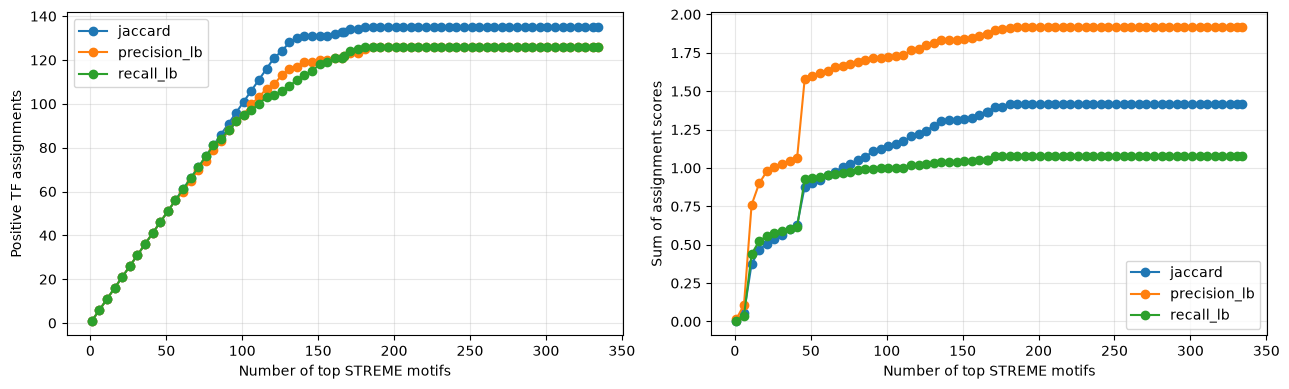

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for metric in metrics:
    current = curves[curves["metric"] == metric]

    axes[0].plot(
        current["rank_t"],
        current["positive_assignments"],
        marker="o",
        label=metric,
    )
    axes[1].plot(
        current["rank_t"],
        current["score_sum"],
        marker="o",
        label=metric,
    )

axes[0].set(
    xlabel="Number of top STREME motifs",
    ylabel="Positive TF assignments",
)
axes[1].set(
    xlabel="Number of top STREME motifs",
    ylabel="Sum of assignment scores",
)

for ax in axes:
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

In [78]:
display(
    curves.sort_values(["metric", "rank_t"])
    .groupby("metric")
    .tail(8)
)

,rank_t,positive_assignments,score_sum,best_score,mean_score,metric,new_positive,score_gain
61,301,135,1.418561,0.285714,0.009990,jaccard,0.0,0.0
62,306,135,1.418561,0.285714,0.009990,jaccard,0.0,0.0
63,311,135,1.418561,0.285714,0.009990,jaccard,0.0,0.0
64,316,135,1.418561,0.285714,0.009990,jaccard,0.0,0.0
65,321,135,1.418561,0.285714,0.009990,jaccard,0.0,0.0
66,326,135,1.418561,0.285714,0.009990,jaccard,0.0,0.0
67,331,135,1.418561,0.285714,0.009990,jaccard,0.0,0.0
68,334,135,1.418561,0.285714,0.009990,jaccard,0.0,0.0
130,301,126,1.916837,0.616141,0.013499,precision_lb,0.0,0.0
131,306,126,1.916837,0.616141,0.013499,precision_lb,0.0,0.0


In [79]:
for metric in metrics:
    df = load_per_rank(run_dir, metric)

    meaningful = (
        df.assign(meaningful=df[metric] >= 0.01)
        .groupby("rank_t")["meaningful"]
        .sum()
    )

    print(metric)
    display(meaningful.tail(10))

jaccard


rank_t
291    22
296    22
301    22
306    22
311    22
316    22
321    22
326    22
331    22
334    22
Name: meaningful, dtype: int64

precision_lb


rank_t
291    17
296    17
301    17
306    17
311    17
316    17
321    17
326    17
331    17
334    17
Name: meaningful, dtype: int64

recall_lb


rank_t
291    12
296    12
301    12
306    12
311    12
316    12
321    12
326    12
331    12
334    12
Name: meaningful, dtype: int64

In [80]:
feature_ranks_path = Path(
    "/s/project/ml4rg_students/2026/project15/working/"
    "binding_bench_inputs/"
    "fimo_streme__saccharomyces_cerevisiae_sequence_mapper_"
    "nmotifs_100_filtered_feature_ranks.parquet"
)

feature_ranks = pd.read_parquet(feature_ranks_path)
n_available = len(feature_ranks)

print("Available filtered motifs:", n_available)

Available filtered motifs: 94


In [81]:
for metric in metrics:
    df = load_per_rank(run_dir, metric)
    df = df[df["rank_t"] <= n_available]

    meaningful = (
        df.assign(meaningful=df[metric] >= 0.01)
        .groupby("rank_t")["meaningful"]
        .sum()
    )

    print(metric)
    display(meaningful.tail(10))

jaccard


rank_t
46    11
51    12
56    12
61    12
66    12
71    13
76    13
81    14
86    14
91    15
Name: meaningful, dtype: int64

precision_lb


rank_t
46    13
51    14
56    14
61    15
66    15
71    15
76    15
81    15
86    15
91    15
Name: meaningful, dtype: int64

recall_lb


rank_t
46    10
51    10
56    10
61    10
66    10
71    10
76    10
81    10
86    10
91    10
Name: meaningful, dtype: int64

In [82]:
for metric in metrics:
    df = load_best(run_dir, metric)

    print(
        metric,
        "meaningful:", (df[metric] >= 0.01).sum(),
        "positive:", (df[metric] > 0).sum(),
        "best:", df[metric].max(),
    )

jaccard meaningful: 22 positive: 135 best: 0.2857142857142857
precision_lb meaningful: 17 positive: 126 best: 0.6161411369412158
recall_lb meaningful: 12 positive: 126 best: 0.3861535957192072


## Comaprision of first 91 nmotifs

In [88]:
common_rank = 91
rows = []

for run_name in ["n100_filtered", "n150_filtered", "n200_filtered", "n100_raw", "n150_raw", "n200_raw"]:
    for metric in metrics:
        df = load_per_rank(runs[run_name], metric)
        current = df[df["rank_t"] == common_rank]

        rows.append({
            "run": run_name,
            "metric": metric,
            "rank_t": common_rank,
            "positive": (current[metric] > 0).sum(),
            "meaningful": (current[metric] >= 0.01).sum(),
            "score_sum": current[metric].sum(),
            "best_score": current[metric].max(),
        })

display(pd.DataFrame(rows))

,run,metric,rank_t,positive,meaningful,score_sum,best_score
0,n100_filtered,jaccard,91,91,17,1.067767,0.285714
1,n100_filtered,precision_lb,91,88,15,1.531779,0.616141
2,n100_filtered,recall_lb,91,85,9,0.865812,0.386154
3,n150_filtered,jaccard,91,91,15,1.128961,0.285714
4,n150_filtered,precision_lb,91,87,15,1.728155,0.616141
5,n150_filtered,recall_lb,91,87,10,0.998593,0.386154
6,n200_filtered,jaccard,91,91,15,1.107148,0.285714
7,n200_filtered,precision_lb,91,88,15,1.715814,0.616141
8,n200_filtered,recall_lb,91,88,10,0.994474,0.386154
9,n100_raw,jaccard,91,91,14,1.030957,0.285714


## Final Baseline creation

Input: S. cerevisiae validation regions; 
STREME: minw=6, maxw=20, nmotifs=150; 
FIMO threshold: 1e-4;
Prediction score: -log10(FIMO p-value);
Position: center of FIMO motif occurrence;
Filtering: low-complexity motifs removed;
Feature ranking: STREME motif order;
Target: DNA_rossi_chipexo;
Metrics: Jaccard, precision_lb, recall_lb;

In [89]:
baseline_run = runs["n150_filtered"]

rows = []

for metric in metrics:
    df = load_best(baseline_run, metric)
    positive = df[df[metric] > 0]
    meaningful = df[df[metric] >= 0.01]
    best = df.loc[df[metric].idxmax()]

    rows.append({
        "method": "STREME-FIMO n150 filtered",
        "metric": metric,
        "assigned": df["feature_idx"].notna().sum(),
        "positive": len(positive),
        "meaningful_ge_0.01": len(meaningful),
        "score_sum": df[metric].sum(),
        "mean_positive": positive[metric].mean(),
        "best_score": best[metric],
        "best_tf": best["name"],
        "best_feature": best["feature_idx"],
    })

baseline_summary = pd.DataFrame(rows)
display(baseline_summary)

,method,metric,assigned,positive,meaningful_ge_0.01,score_sum,mean_positive,best_score,best_tf,best_feature
0,STREME-FIMO n150 filtered,jaccard,139,133,21,1.389491,0.010447,0.285714,ume6,13-TAGCCGCCGARG
1,STREME-FIMO n150 filtered,precision_lb,139,122,16,1.884518,0.015447,0.616141,ume6,13-TAGCCGCCGARG
2,STREME-FIMO n150 filtered,recall_lb,139,120,11,1.063797,0.008865,0.386154,ume6,13-TAGCCGCCGARG


In [90]:
baseline_summary.to_csv(
    "/s/project/ml4rg_students/2026/project15/working/"
    "binding_bench_runs/streme_fimo_n150_filtered_baseline.tsv",
    sep="\t",
    index=False,
)

## Visualization of choice

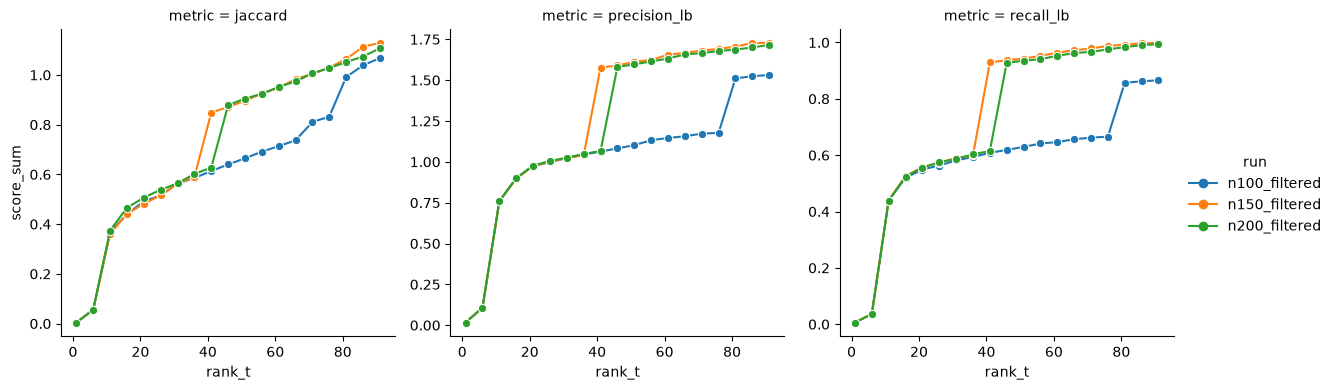

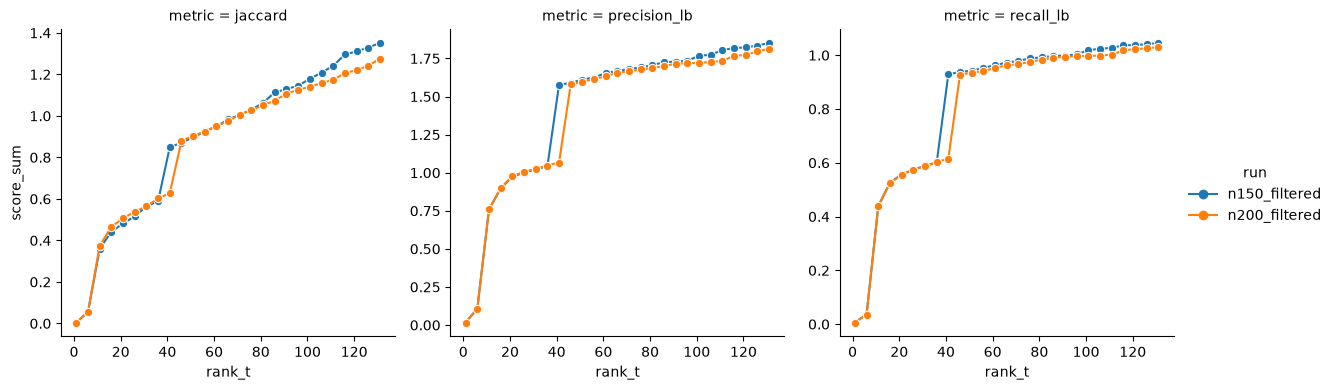

In [98]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

curve_rows = []

for run_name in ["n100_filtered", "n150_filtered", "n200_filtered"]:
    for metric in metrics:
        df = load_per_rank(runs[run_name], metric)
        df = df[df["rank_t"] <= 91]

        summary = (
            df.groupby("rank_t")
            .agg(
                score_sum=(metric, "sum"),
                meaningful=(metric, lambda x: (x >= 0.01).sum()),
            )
            .reset_index()
        )
        summary["run"] = run_name
        summary["metric"] = metric
        curve_rows.append(summary)

curves = pd.concat(curve_rows, ignore_index=True)

sns.relplot(
    data=curves,
    x="rank_t",
    y="score_sum",
    hue="run",
    col="metric",
    kind="line",
    marker="o",
    facet_kws={"sharey": False},
    height=4,
)
plt.show()

curve_rows = []

for run_name in [ "n150_filtered", "n200_filtered"]:
    for metric in metrics:
        df = load_per_rank(runs[run_name], metric)
        df = df[df["rank_t"] <= 131]

        summary = (
            df.groupby("rank_t")
            .agg(
                score_sum=(metric, "sum"),
                meaningful=(metric, lambda x: (x >= 0.01).sum()),
            )
            .reset_index()
        )
        summary["run"] = run_name
        summary["metric"] = metric
        curve_rows.append(summary)

curves = pd.concat(curve_rows, ignore_index=True)

sns.relplot(
    data=curves,
    x="rank_t",
    y="score_sum",
    hue="run",
    col="metric",
    kind="line",
    marker="o",
    facet_kws={"sharey": False},
    height=4,
)
plt.show()

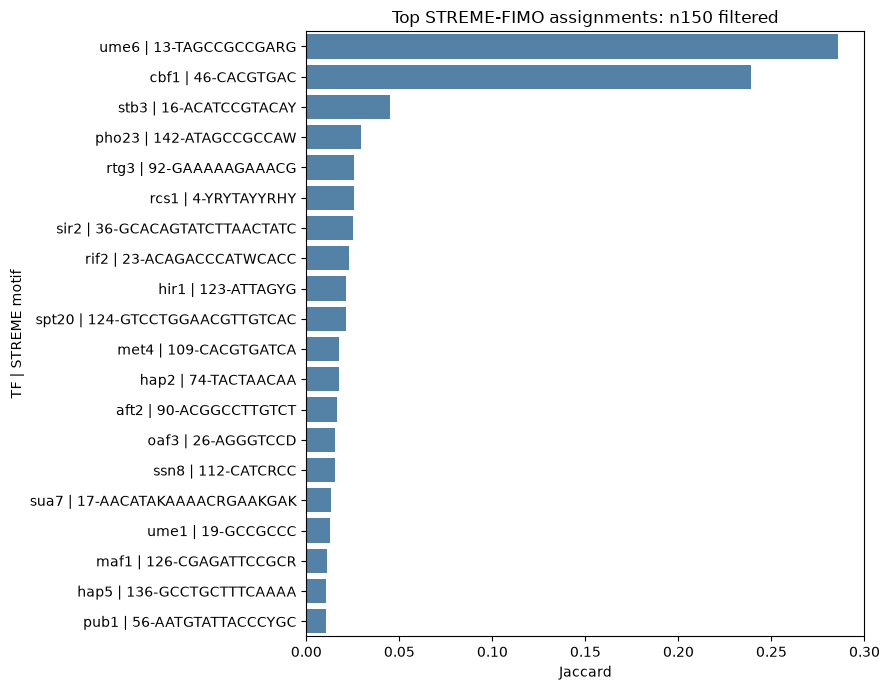

In [95]:
baseline = load_best(runs["n150_filtered"], "jaccard")

top = (
    baseline.dropna(subset=["feature_idx"])
    .query("jaccard > 0")
    .nlargest(20, "jaccard")
    .copy()
)

top["label"] = top["name"] + " | " + top["feature_idx"]

plt.figure(figsize=(9, 7))
sns.barplot(
    data=top,
    x="jaccard",
    y="label",
    color="steelblue",
)
plt.title("Top STREME-FIMO assignments: n150 filtered")
plt.xlabel("Jaccard")
plt.ylabel("TF | STREME motif")
plt.tight_layout()
plt.show()

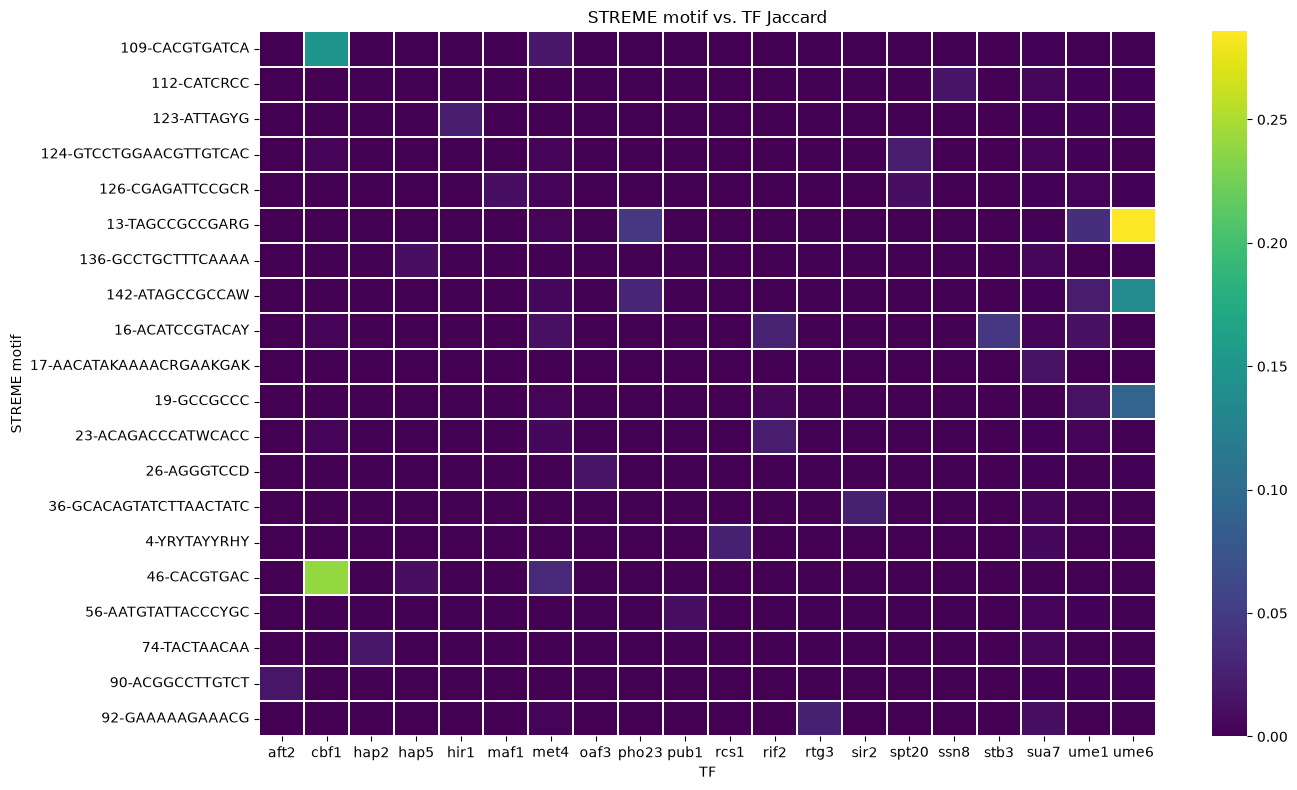

In [96]:
full_path = (
    runs["n150_filtered"]
    / "full_discrete_metrics_ds_DNA_rossi_chipexo.parquet"
)
full = pd.read_parquet(full_path)

top_features = top["feature_idx"].unique()
top_tfs = top["name"].unique()

matrix = (
    full[
        full["feature_idx"].isin(top_features)
        & full["name"].isin(top_tfs)
    ]
    .pivot_table(
        index="feature_idx",
        columns="name",
        values="jaccard",
        aggfunc="max",
        fill_value=0,
    )
)

plt.figure(figsize=(14, 8))
sns.heatmap(matrix, cmap="viridis", linewidths=0.2)
plt.title("STREME motif vs. TF Jaccard")
plt.xlabel("TF")
plt.ylabel("STREME motif")
plt.tight_layout()
plt.show()